# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
**Answer: We use general linear models/latent variable models/activation functions because they can model outcomes that ordinary linear regression does not handle well. A regular linear model can predict any real number, which is not ideal for probabilities or class labels. Logistic-style models solve this by first forming a linear combination of the features and then passing it through an activation function like the sigmoid so the output stays between 0 and 1.**

2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
**Answer: Binary and categorical cross entropy are effective because they directly compare the model’s predicted probabilities to the true class labels. They penalize confident wrong predictions heavily, which makes them especially useful for classification. They also match the likelihood-based setup of logistic regression, so minimizing cross entropy gives parameter values that make the observed data as likely as possible.**


3. True or false, and explain: Logistic regression is a linear model.
**Answer: True, with clarification: Logistic regression is linear in the latent score or log-odds, but not linear in the final predicted probability. The model forms a linear combination of the features first, then applies the logistic function to produce a probability.**

4. True or false, and explain: Logistic regression cannot be used for classification.
**Answer: False: Logistic regression can be used for classification. It predicts class probabilities, and then those probabilities can be converted into class labels using a cutoff such as 0.5 in the binary case.**

1. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
**Answer: No: In logistic regression, a coefficient does not directly represent the change in predicted probability for a one-unit increase in a feature. Instead, it represents the change in the log-odds of the outcome for a one-unit increase in that feature, holding the other variables fixed.**

1. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
**Answer: False: Feature engineering is still important in logistic regression. Even though the final output is produced through a nonlinear sigmoid function, the model is still based on a linear combination of the input features. If the real relationship depends on interactions, polynomial terms, or other transformations, those still need to be added manually.**

1. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.
**Answer: False: Logistic regression is better when the outcome is categorical, especially binary, because it produces valid probabilities and uses a classification-based loss. Ordinary least squares is still more appropriate when the outcome is continuous.**

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


In [81]:
# Q2.1
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/data.csv', sep=';')

# Select relevant columns
columns_to_keep = ['Debtor', 'Tuition fees up to date', 'Scholarship holder', 
                   'Age at enrollment', 'Curricular units 1st sem (approved)', 'Target']
df = df[columns_to_keep]

# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
#in this case we did not have to deal with missing values as there were none. 


df = df.dropna()

print(f"\nDataset shape after handling missing values: {df.shape}")
print(f"\nTarget distribution:\n{df['Target'].value_counts()}")

# Create binary target: 1 for Dropout, 0 for Graduate or Enrolled
df['Dropout_Binary'] = (df['Target'] == 'Dropout').astype(int)

print(f"\nBinary target distribution:\n{df['Dropout_Binary'].value_counts()}")

Missing values per column:
Debtor                                 0
Tuition fees up to date                0
Scholarship holder                     0
Age at enrollment                      0
Curricular units 1st sem (approved)    0
Target                                 0
dtype: int64

Dataset shape after handling missing values: (4424, 6)

Target distribution:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Binary target distribution:
Dropout_Binary
0    3003
1    1421
Name: count, dtype: int64


In [82]:
# Q2.2 - Logistic regression for dropout prediction
X = df[['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment']]
y = df['Dropout_Binary']

log_reg = LogisticRegression(penalty=None, random_state=42, max_iter=1000)
log_reg.fit(X, y)

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_reg.coef_[0],
    'Odds Ratio': np.exp(log_reg.coef_[0])
})
coef_df['Direction'] = coef_df['Coefficient'].apply(
    lambda x: 'Higher dropout' if x > 0 else 'Lower dropout'
)

print("Logistic Regression Coefficients:")
print(coef_df)
print(f"\nIntercept: {log_reg.intercept_[0]:.4f}")

print("\n--- Interpretation ---")
print("Positive coefficients predict HIGHER dropout probability:")
for idx, row in coef_df[coef_df['Coefficient'] > 0].iterrows():
    print(f"  - {row['Feature']}: coef={row['Coefficient']:.4f}, odds ratio={row['Odds Ratio']:.4f}")

print("\nNegative coefficients predict LOWER dropout probability:")
for idx, row in coef_df[coef_df['Coefficient'] < 0].iterrows():
    print(f"  - {row['Feature']}: coef={row['Coefficient']:.4f}, odds ratio={row['Odds Ratio']:.4f}")

tuition_effect = coef_df[coef_df['Feature'] == 'Tuition fees up to date']['Coefficient'].values[0]
print(f"\nCoefficient for Tuition fees up to date: {tuition_effect:.4f}")
if tuition_effect < 0:
    print("Being up to date on tuition appears to REDUCE dropout risk.")
else:
    print("Being up to date on tuition appears to INCREASE dropout risk.")

Logistic Regression Coefficients:
                   Feature  Coefficient  Odds Ratio       Direction
0                   Debtor     0.527137    1.694076  Higher dropout
1  Tuition fees up to date    -2.605617    0.073858   Lower dropout
2       Scholarship holder    -1.242299    0.288720   Lower dropout
3        Age at enrollment     0.049841    1.051104  Higher dropout

Intercept: 0.5353

--- Interpretation ---
Positive coefficients predict HIGHER dropout probability:
  - Debtor: coef=0.5271, odds ratio=1.6941
  - Age at enrollment: coef=0.0498, odds ratio=1.0511

Negative coefficients predict LOWER dropout probability:
  - Tuition fees up to date: coef=-2.6056, odds ratio=0.0739
  - Scholarship holder: coef=-1.2423, odds ratio=0.2887

Coefficient for Tuition fees up to date: -2.6056
Being up to date on tuition appears to REDUCE dropout risk.


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


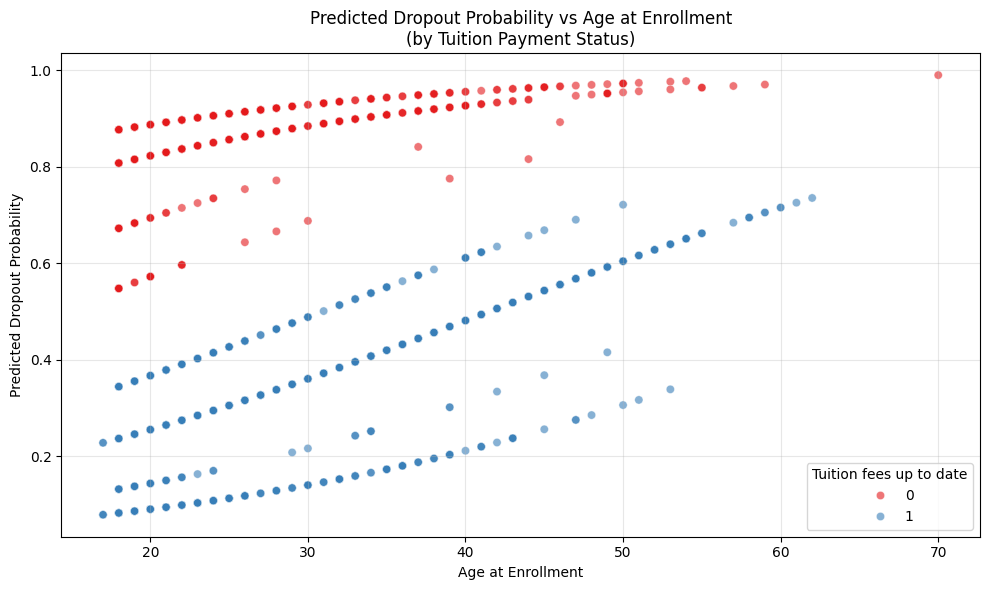

Average change in predicted dropout probability when tuition changes from 0 to 1:
-0.5233

Age where being up to date on tuition reduces dropout probability the most:
22
Maximum reduction: -0.5448

Interpretation:
A negative value means being up to date on tuition lowers predicted dropout probability.


In [83]:
# Q2.3
df['Predicted_Dropout_Prob'] = log_reg.predict_proba(X)[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='Age at enrollment',
    y='Predicted_Dropout_Prob',
    hue='Tuition fees up to date',
    alpha=0.6,
    palette='Set1'
)
plt.xlabel('Age at Enrollment')
plt.ylabel('Predicted Dropout Probability')
plt.title('Predicted Dropout Probability vs Age at Enrollment\n(by Tuition Payment Status)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

X_tuition0 = X.copy()
X_tuition1 = X.copy()

X_tuition0['Tuition fees up to date'] = 0
X_tuition1['Tuition fees up to date'] = 1

prob_if_0 = log_reg.predict_proba(X_tuition0)[:, 1]
prob_if_1 = log_reg.predict_proba(X_tuition1)[:, 1]

df['Tuition_Effect'] = prob_if_1 - prob_if_0   # negative = tuition up to date lowers dropout

avg_effect = df['Tuition_Effect'].mean()

effect_by_age = df.groupby('Age at enrollment')['Tuition_Effect'].mean().dropna()

print("Average change in predicted dropout probability when tuition changes from 0 to 1:")
print(f"{avg_effect:.4f}")

print("\nAge where being up to date on tuition reduces dropout probability the most:")
print(effect_by_age.idxmin())
print(f"Maximum reduction: {effect_by_age.min():.4f}")

print("\nInterpretation:")
print("A negative value means being up to date on tuition lowers predicted dropout probability.")

Confusion Matrix:
[[2841  162]
 [ 891  530]]

Accuracy: 0.7620


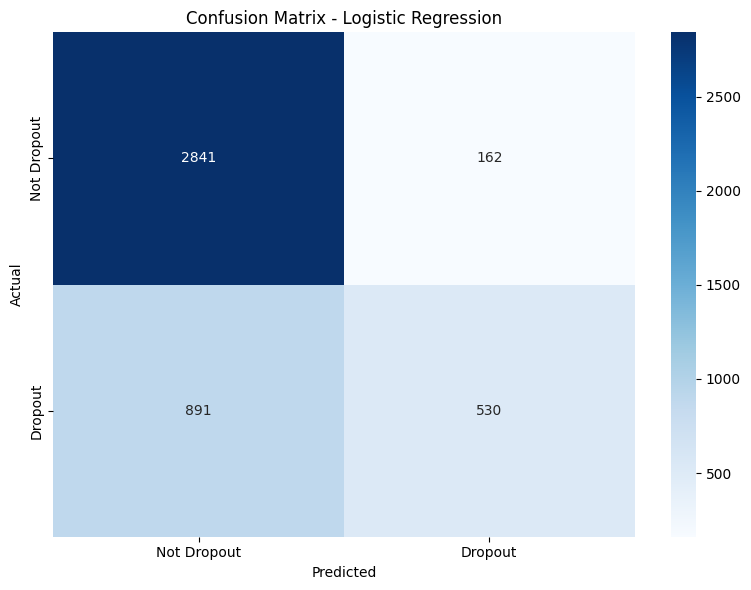

In [84]:
# Q2.4
y_pred = log_reg.predict(X)

cm = confusion_matrix(y, y_pred)
accuracy = accuracy_score(y, y_pred)

print("Confusion Matrix:")
print(cm)
print(f"\nAccuracy: {accuracy:.4f}")

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Dropout', 'Dropout'],
    yticklabels=['Not Dropout', 'Dropout']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.tight_layout()
plt.show()

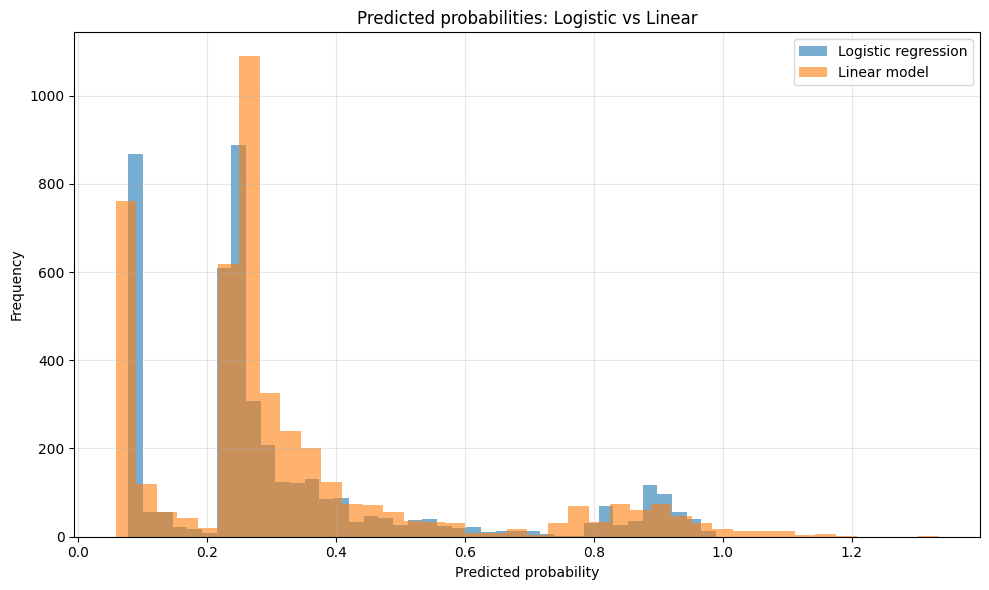

Logistic Regression Accuracy: 0.762
Linear Model Accuracy: 0.7633

Linear Model Predictions:
  Min: 0.0583
  Max: 1.3350
  Predictions < 0: 0
  Predictions > 1: 57

Logistic Regression Predictions:
  Min: 0.0783
  Max: 0.9896


In [85]:
# Q2.5
lin_reg = LinearRegression()
lin_reg.fit(X, y)

df['Linear_Pred_Prob'] = lin_reg.predict(X)

plt.figure(figsize=(10, 6))
plt.hist(df['Predicted_Dropout_Prob'], bins=40, alpha=0.6, label='Logistic regression')
plt.hist(df['Linear_Pred_Prob'], bins=40, alpha=0.6, label='Linear model')
plt.xlabel('Predicted probability')
plt.ylabel('Frequency')
plt.title('Predicted probabilities: Logistic vs Linear')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

linear_pred_binary = (df['Linear_Pred_Prob'] >= 0.5).astype(int)
linear_accuracy = accuracy_score(y, linear_pred_binary)

print("Logistic Regression Accuracy:", round(accuracy, 4))
print("Linear Model Accuracy:", round(linear_accuracy, 4))
print()

print("Linear Model Predictions:")
print(f"  Min: {df['Linear_Pred_Prob'].min():.4f}")
print(f"  Max: {df['Linear_Pred_Prob'].max():.4f}")
print(f"  Predictions < 0: {(df['Linear_Pred_Prob'] < 0).sum()}")
print(f"  Predictions > 1: {(df['Linear_Pred_Prob'] > 1).sum()}")

print("\nLogistic Regression Predictions:")
print(f"  Min: {df['Predicted_Dropout_Prob'].min():.4f}")
print(f"  Max: {df['Predicted_Dropout_Prob'].max():.4f}")

In [86]:
# Q2.6 
print("=== Most At-Risk Students ===")

high_risk = df[df['Predicted_Dropout_Prob'] > 0.7]

print(f"\nNumber of high-risk students (>70% dropout probability): {len(high_risk)}")
print(f"\nCharacteristics of high-risk students:")
print(high_risk[['Debtor', 'Tuition fees up to date', 'Scholarship holder', 
                 'Age at enrollment', 'Predicted_Dropout_Prob']].describe())

print("\n--- Student Profiles Most At Risk ---")
print("Based on the logistic regression coefficients:")
print("- Students who are debtors (if positive coefficient)")
print("- Students NOT up to date on tuition fees (if negative coefficient)")
print("- Students without scholarships (if negative coefficient)")  
print("- Older/younger students (depending on age coefficient sign)")

print("\n--- Recommended Interventions ---")
print("1. Financial Support:")
print("   - Emergency grants for students behind on tuition")
print("   - Expanded scholarship programs")
print("   - Financial counseling and debt management")
print("")
print("2. Early Warning System:")
print("   - Monitor students with multiple risk factors")
print("   - Proactive outreach when tuition payments are late")
print("")
print("3. Academic Support:")
print("   - Tutoring programs for struggling students")
print("   - Flexible payment plans to reduce financial stress")
print("")
print("4. Student Engagement:")
print("   - Mentorship programs")
print("   - Social integration activities")
print("   - Career counseling to maintain motivation")

=== Most At-Risk Students ===

Number of high-risk students (>70% dropout probability): 501

Characteristics of high-risk students:
           Debtor  Tuition fees up to date  Scholarship holder  \
count  501.000000               501.000000          501.000000   
mean     0.467066                 0.013972            0.023952   
std      0.499413                 0.117492            0.153053   
min      0.000000                 0.000000            0.000000   
25%      0.000000                 0.000000            0.000000   
50%      0.000000                 0.000000            0.000000   
75%      1.000000                 0.000000            0.000000   
max      1.000000                 1.000000            1.000000   

       Age at enrollment  Predicted_Dropout_Prob  
count         501.000000              501.000000  
mean           27.856287                0.880287  
std             9.760907                0.053492  
min            18.000000                0.704081  
25%            20.

In [87]:
# Q2.7 
X_multi = df[['Debtor', 'Tuition fees up to date', 'Curricular units 1st sem (approved)']]
y_multi = df['Target']

multi_log_reg = LogisticRegression(random_state=42, max_iter=1000)
multi_log_reg.fit(X_multi, y_multi)

y_multi_pred = multi_log_reg.predict(X_multi)

classes = multi_log_reg.classes_
cm_multi = confusion_matrix(y_multi, y_multi_pred, labels=classes)

print("Multiclass Logistic Regression Results")
print("=" * 50)
print("\nClasses:", classes)
print("\nConfusion Matrix:")
print(pd.DataFrame(cm_multi, index=classes, columns=classes))

multi_accuracy = accuracy_score(y_multi, y_multi_pred)
print(f"\nAccuracy: {multi_accuracy:.4f}")

print("\nUnique predicted classes:")
print(pd.Series(y_multi_pred).value_counts())

y_multi_proba = multi_log_reg.predict_proba(X_multi)
proba_df = pd.DataFrame(y_multi_proba, columns=classes)

print("\nFirst 5 predicted probability rows:")
print(proba_df.head())

print("\nMean probability for each class:")
print(proba_df.mean())

Multiclass Logistic Regression Results

Classes: ['Dropout' 'Enrolled' 'Graduate']

Confusion Matrix:
          Dropout  Enrolled  Graduate
Dropout      1054         0       367
Enrolled      280         0       514
Graduate      146         0      2063

Accuracy: 0.7046

Unique predicted classes:
Graduate    2944
Dropout     1480
Name: count, dtype: int64

First 5 predicted probability rows:
    Dropout  Enrolled  Graduate
0  0.680547  0.210464  0.108989
1  0.695414  0.146043  0.158543
2  0.952988  0.041199  0.005813
3  0.117808  0.176983  0.705209
4  0.184227  0.212669  0.603104

Mean probability for each class:
Dropout     0.321223
Enrolled    0.179474
Graduate    0.499303
dtype: float64


**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics 
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class? 

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import confusion_matrix, accuracy_score

# Q3.1

try:
    cirrhosis_df = pd.read_csv("cirrhosis.csv")
except FileNotFoundError:
    cirrhosis_df = pd.read_csv("data/cirrhosis.csv")

q3_cols = ["Bilirubin", "Edema", "Drug", "Stage", "Status"]
cirrhosis_df = cirrhosis_df[q3_cols].copy()

print("Missing values per column:")
print(cirrhosis_df.isnull().sum())
print()

# Drop rows missing Drug since Drug is required in the model
q3_survival = cirrhosis_df.dropna(subset=["Drug"]).copy()

print("Dataset shape after handling missing Drug values:", q3_survival.shape)
print()
print("Status distribution:")
print(q3_survival["Status"].value_counts())
print()
print("Edema distribution:")
print(q3_survival["Edema"].value_counts())
print()
print("Drug distribution:")
print(q3_survival["Drug"].value_counts())
print()

# survived = 1 if C or CL, else 0 if D
q3_survival["Survived"] = q3_survival["Status"].isin(["C", "CL"]).astype(int)

# Drug_Dpen = 1 means patient took D-penicillamine
# Edema_Ordinal: N=0, S=1, Y=2
q3_survival["Drug_Dpen"] = (q3_survival["Drug"] == "D-penicillamine").astype(int)
q3_survival["Edema_Ordinal"] = q3_survival["Edema"].map({"N": 0, "S": 1, "Y": 2})

print("Coding check:")
print("Drug_Dpen: 1 = D-penicillamine, 0 = Placebo")
print("Edema_Ordinal: N=0, S=1, Y=2")
print()

Missing values per column:
Bilirubin      0
Edema          0
Drug         106
Stage          6
Status         0
dtype: int64

Dataset shape after handling missing Drug values: (312, 5)

Status distribution:
Status
C     168
D     125
CL     19
Name: count, dtype: int64

Edema distribution:
Edema
N    263
S     29
Y     20
Name: count, dtype: int64

Drug distribution:
Drug
D-penicillamine    158
Placebo            154
Name: count, dtype: int64

Coding check:
Drug_Dpen: 1 = D-penicillamine, 0 = Placebo
Edema_Ordinal: N=0, S=1, Y=2



In [89]:
#Q3.2
X_cirr = q3_survival[["Edema_Ordinal", "Drug_Dpen", "Bilirubin"]]
y_cirr = q3_survival["Survived"]

log_reg_cirr = LogisticRegression(random_state=42, max_iter=1000)
log_reg_cirr.fit(X_cirr, y_cirr)

coef_df_cirr = pd.DataFrame({
    "Feature": X_cirr.columns,
    "Coefficient": log_reg_cirr.coef_[0],
    "Odds Ratio": np.exp(log_reg_cirr.coef_[0])
})

print("Q3.2 Logistic Regression Coefficients:")
print(coef_df_cirr)
print(f"\nIntercept: {log_reg_cirr.intercept_[0]:.4f}")

drug_coef = coef_df_cirr.loc[coef_df_cirr["Feature"] == "Drug_Dpen", "Coefficient"].iloc[0]
bili_coef = coef_df_cirr.loc[coef_df_cirr["Feature"] == "Bilirubin", "Coefficient"].iloc[0]
edema_coef = coef_df_cirr.loc[coef_df_cirr["Feature"] == "Edema_Ordinal", "Coefficient"].iloc[0]

print("\n--- Interpretation ---")
print(f"Drug_Dpen coefficient = {drug_coef:.4f}")
if drug_coef > 0:
    print("D-penicillamine appears to improve survival probability.")
else:
    print("D-penicillamine does not appear to improve survival probability.")

print(f"\nBilirubin coefficient = {bili_coef:.4f}")
if bili_coef > 0:
    print("Higher bilirubin predicts a higher survival probability.")
else:
    print("Higher bilirubin predicts a lower survival probability.")

print(f"\nEdema coefficient = {edema_coef:.4f}")
if edema_coef > 0:
    print("As edema severity increases, survival probability increases.")
else:
    print("As edema severity increases, survival probability decreases.")



Q3.2 Logistic Regression Coefficients:
         Feature  Coefficient  Odds Ratio
0  Edema_Ordinal    -0.915295    0.400399
1      Drug_Dpen    -0.223469    0.799739
2      Bilirubin    -0.348584    0.705687

Intercept: 1.6498

--- Interpretation ---
Drug_Dpen coefficient = -0.2235
D-penicillamine does not appear to improve survival probability.

Bilirubin coefficient = -0.3486
Higher bilirubin predicts a lower survival probability.

Edema coefficient = -0.9153
As edema severity increases, survival probability decreases.


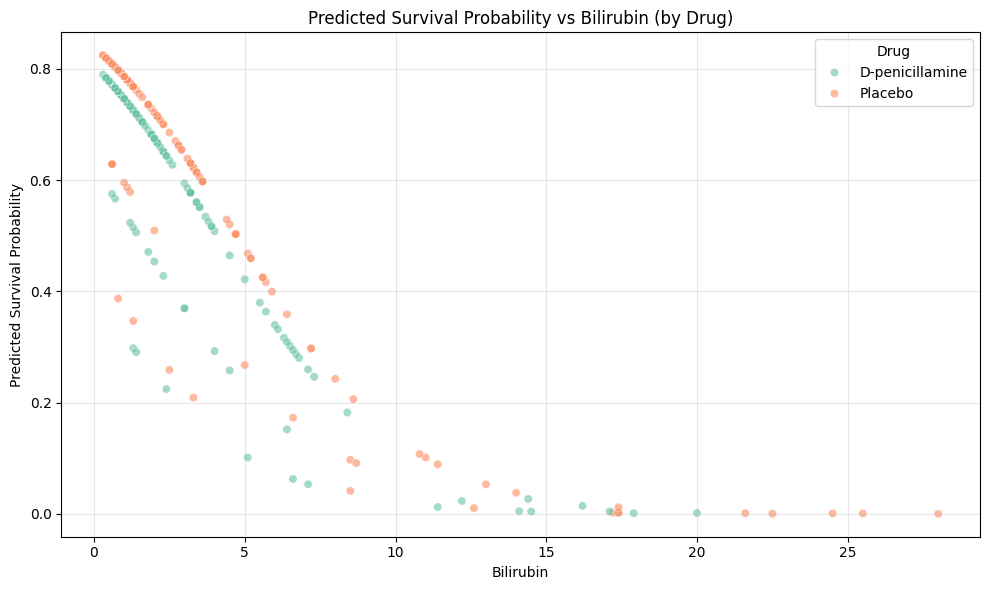


Q3.3 Average change in predicted survival probability when switching from Placebo to D-penicillamine:
-0.0404

Drug effect by Bilirubin bin:
Bili_Bin
(0.272, 3.07]    -0.042014
(3.07, 5.84]     -0.052648
(5.84, 8.61]     -0.039011
(8.61, 11.38]    -0.018388
(11.38, 14.15]   -0.006578
(14.15, 16.92]   -0.003699
(16.92, 19.69]   -0.000825
(19.69, 22.46]   -0.000307
(22.46, 25.23]   -0.000134
(25.23, 28.0]    -0.000084
Name: Drug_Effect, dtype: float64

There is no bilirubin range where the drug increases predicted survival.
The least negative effect occurs in:
(25.23, 28.0]
Least negative effect: -0.0001

Interpretation:
On average, the drug decreases predicted survival probability.


In [90]:
# Q3.3 
q3_survival["Predicted_Survival_Prob"] = log_reg_cirr.predict_proba(X_cirr)[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=q3_survival,
    x="Bilirubin",
    y="Predicted_Survival_Prob",
    hue="Drug",
    alpha=0.6,
    palette="Set2"
)
plt.xlabel("Bilirubin")
plt.ylabel("Predicted Survival Probability")
plt.title("Predicted Survival Probability vs Bilirubin (by Drug)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

X_placebo = X_cirr.copy()
X_drug = X_cirr.copy()

X_placebo["Drug_Dpen"] = 0
X_drug["Drug_Dpen"] = 1

prob_if_placebo = log_reg_cirr.predict_proba(X_placebo)[:, 1]
prob_if_drug = log_reg_cirr.predict_proba(X_drug)[:, 1]

q3_survival["Drug_Effect"] = prob_if_drug - prob_if_placebo

avg_drug_effect = q3_survival["Drug_Effect"].mean()

effect_by_bili_bin = (
    q3_survival.assign(Bili_Bin=pd.cut(q3_survival["Bilirubin"], bins=10))
    .groupby("Bili_Bin", observed=False)["Drug_Effect"]
    .mean()
    .dropna()
)

print("\nQ3.3 Average change in predicted survival probability when switching from Placebo to D-penicillamine:")
print(f"{avg_drug_effect:.4f}")

if len(effect_by_bili_bin) > 0:
    print("\nDrug effect by Bilirubin bin:")
    print(effect_by_bili_bin)

    if effect_by_bili_bin.max() > 0:
        print("\nBilirubin bin where the drug increases survival the most:")
        print(effect_by_bili_bin.idxmax())
        print(f"Maximum increase in survival probability: {effect_by_bili_bin.max():.4f}")
    else:
        print("\nThere is no bilirubin range where the drug increases predicted survival.")
        print("The least negative effect occurs in:")
        print(effect_by_bili_bin.idxmax())
        print(f"Least negative effect: {effect_by_bili_bin.max():.4f}")
else:
    print("\nNo bilirubin bins available for comparison.")

print("\nInterpretation:")
if avg_drug_effect > 0:
    print("On average, the drug increases predicted survival probability.")
else:
    print("On average, the drug decreases predicted survival probability.")


Q3.4 Confusion Matrix:
[[ 60  65]
 [ 14 173]]

Q3.4 Accuracy: 0.7468


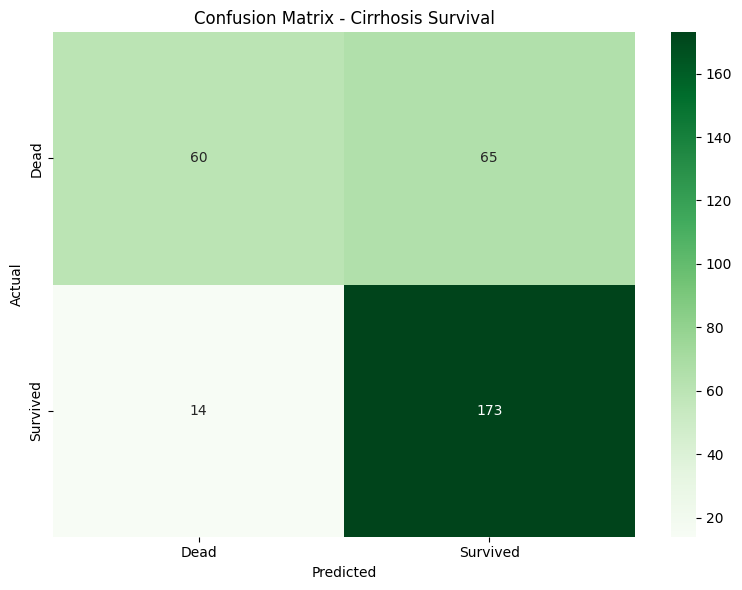

In [91]:
# Q3.4 
y_cirr_pred = log_reg_cirr.predict(X_cirr)

cm_cirr = confusion_matrix(y_cirr, y_cirr_pred)
accuracy_cirr = accuracy_score(y_cirr, y_cirr_pred)

print("\nQ3.4 Confusion Matrix:")
print(cm_cirr)
print(f"\nQ3.4 Accuracy: {accuracy_cirr:.4f}")

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_cirr,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Dead", "Survived"],
    yticklabels=["Dead", "Survived"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Cirrhosis Survival")
plt.tight_layout()
plt.show()

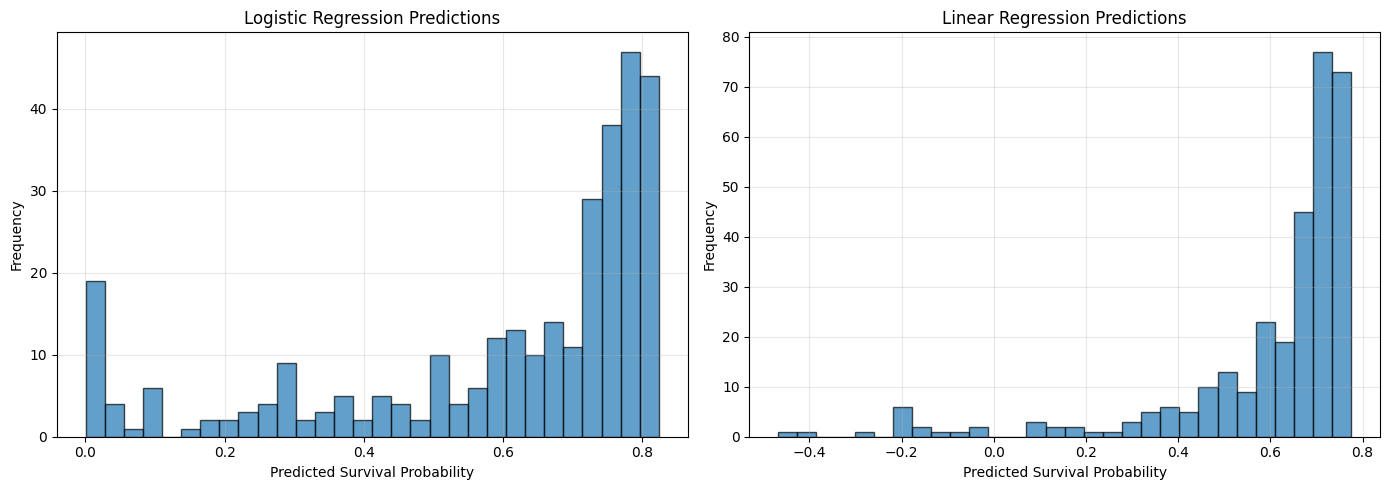

Q3.5 Linear Model Predictions:
  Min: -0.4678
  Max: 0.7757
  Predictions < 0: 15
  Predictions > 1: 0

Q3.5 Logistic Regression Predictions:
  Min: 0.0001
  Max: 0.8242

Q3.5 Logistic Regression Accuracy: 0.7468
Q3.5 Linear Model Accuracy: 0.7276

Performance comparison:
Linear regression can produce invalid probabilities outside [0,1].
Logistic regression keeps probabilities in the valid range.


In [92]:
#3.5)
lin_reg_cirr = LinearRegression()
lin_reg_cirr.fit(X_cirr, y_cirr)

q3_survival["Linear_Survival_Prob"] = lin_reg_cirr.predict(X_cirr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(q3_survival["Predicted_Survival_Prob"], bins=30, alpha=0.7, edgecolor="black")
axes[0].set_xlabel("Predicted Survival Probability")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Logistic Regression Predictions")
axes[0].grid(True, alpha=0.3)

axes[1].hist(q3_survival["Linear_Survival_Prob"], bins=30, alpha=0.7, edgecolor="black")
axes[1].set_xlabel("Predicted Survival Probability")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Linear Regression Predictions")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

linear_cirr_pred = (q3_survival["Linear_Survival_Prob"] >= 0.5).astype(int)
linear_cirr_accuracy = accuracy_score(y_cirr, linear_cirr_pred)

print("Q3.5 Linear Model Predictions:")
print(f"  Min: {q3_survival['Linear_Survival_Prob'].min():.4f}")
print(f"  Max: {q3_survival['Linear_Survival_Prob'].max():.4f}")
print(f"  Predictions < 0: {(q3_survival['Linear_Survival_Prob'] < 0).sum()}")
print(f"  Predictions > 1: {(q3_survival['Linear_Survival_Prob'] > 1).sum()}")

print("\nQ3.5 Logistic Regression Predictions:")
print(f"  Min: {q3_survival['Predicted_Survival_Prob'].min():.4f}")
print(f"  Max: {q3_survival['Predicted_Survival_Prob'].max():.4f}")

print(f"\nQ3.5 Logistic Regression Accuracy: {accuracy_cirr:.4f}")
print(f"Q3.5 Linear Model Accuracy: {linear_cirr_accuracy:.4f}")

print("\nPerformance comparison:")
print("Linear regression can produce invalid probabilities outside [0,1].")
print("Logistic regression keeps probabilities in the valid range.")




Q3.6 Logistic Regression for Stage Prediction

Confusion Matrix:
   1  2    3   4
1  0  0   20   1
2  0  0   82  10
3  0  0  131  24
4  0  0   94  50


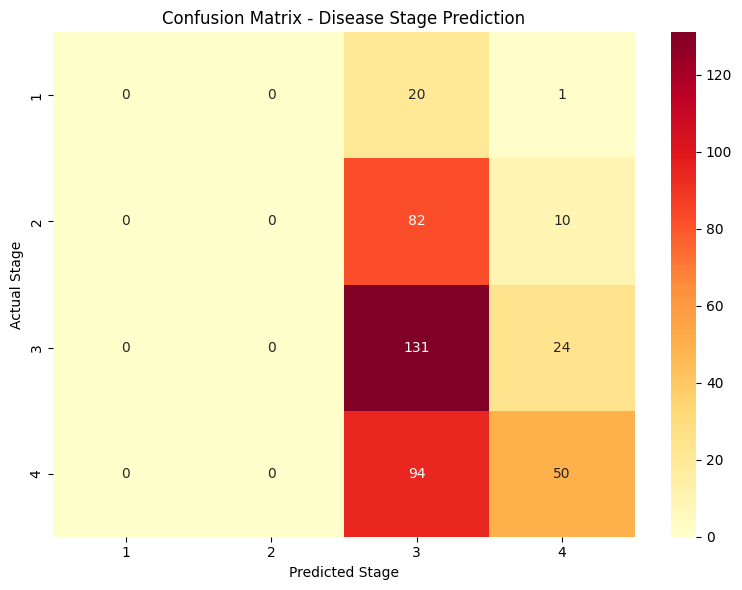


Q3.6 Accuracy: 0.4393

Unique predicted stages:
[3 4]

Does hard classification predict every stage?
False

First 5 predicted probability rows:
          1         2         3         4
0  0.000213  0.029793  0.134265  0.835729
1  0.069529  0.255473  0.399149  0.275849
2  0.035862  0.144005  0.325101  0.495033
3  0.031728  0.141960  0.323740  0.502572
4  0.035805  0.245060  0.405773  0.313363

Mean probability for each stage:
1    0.050952
2    0.223309
3    0.376251
4    0.349488
dtype: float64

Per-stage probability / hard-prediction summary:
Stage 1: max probability = 0.0869, hard predictions = 0
Stage 2: max probability = 0.2573, hard predictions = 0
Stage 3: max probability = 0.4059, hard predictions = 327
Stage 4: max probability = 0.8857, hard predictions = 85


In [93]:
#3.6)

q3_stage = cirrhosis_df.dropna(subset=["Stage"]).copy()
q3_stage["Stage"] = q3_stage["Stage"].astype(int)
q3_stage["Edema_Ordinal"] = q3_stage["Edema"].map({"N": 0, "S": 1, "Y": 2})

X_stage = q3_stage[["Edema_Ordinal", "Bilirubin"]]
y_stage = q3_stage["Stage"]

log_reg_stage = LogisticRegression(random_state=42, max_iter=1000)
log_reg_stage.fit(X_stage, y_stage)

y_stage_pred = log_reg_stage.predict(X_stage)

stages = np.sort(y_stage.unique())
cm_stage = confusion_matrix(y_stage, y_stage_pred, labels=stages)

print("\nQ3.6 Logistic Regression for Stage Prediction")
print("=" * 50)
print("\nConfusion Matrix:")
print(pd.DataFrame(cm_stage, index=stages, columns=stages))

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_stage,
    annot=True,
    fmt="d",
    cmap="YlOrRd",
    xticklabels=stages,
    yticklabels=stages
)
plt.xlabel("Predicted Stage")
plt.ylabel("Actual Stage")
plt.title("Confusion Matrix - Disease Stage Prediction")
plt.tight_layout()
plt.show()

stage_accuracy = accuracy_score(y_stage, y_stage_pred)
print(f"\nQ3.6 Accuracy: {stage_accuracy:.4f}")

print("\nUnique predicted stages:")
print(np.sort(np.unique(y_stage_pred)))

print("\nDoes hard classification predict every stage?")
print(set(y_stage_pred) == set(y_stage))

y_stage_proba = log_reg_stage.predict_proba(X_stage)
proba_stage_df = pd.DataFrame(y_stage_proba, columns=log_reg_stage.classes_)

print("\nFirst 5 predicted probability rows:")
print(proba_stage_df.head())

print("\nMean probability for each stage:")
print(proba_stage_df.mean())

print("\nPer-stage probability / hard-prediction summary:")
for i, stage in enumerate(log_reg_stage.classes_):
    print(
        f"Stage {stage}: "
        f"max probability = {y_stage_proba[:, i].max():.4f}, "
        f"hard predictions = {(y_stage_pred == stage).sum()}"
    )

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio? 

**4.1**

For the linear model, the derivative with respect to the $k$-th feature is $b_k$. So if $x_k$ goes up by 1 unit, the prediction changes by exactly $b_k$. In other words, the coefficient in a linear model tells you the direct change in the prediction for a 1-unit increase in that feature. This does not depend on the current value of $x_k$, so the effect is constant.

**4.2**
Using the chain rule,

$$
\frac{\partial \hat{p}}{\partial x_k}
=
\frac{\partial \hat{p}}{\partial L}
\cdot
\frac{\partial L}{\partial x_k}
$$

We know that
$\frac{\partial \hat{p}}{\partial L} = \hat{p}(1-\hat{p})$ and $\frac{\partial L}{\partial x_k} = b_k$, so
$\frac{\partial \hat{p}}{\partial x_k} = b_k \hat{p}(1-\hat{p})$

This is different from the linear model because the effect is not constant anymore. It depends on the current value of $\hat{p}$. If $\hat{p}$ is close to 0 or 1, then $\hat{p}(1-\hat{p})$ is small, so the feature changes the prediction less. If $\hat{p}$ is close to 0.5, then $\hat{p}(1-\hat{p})$ is largest, so the feature has the biggest effect there.

Since the biggest possible value of $\hat{p}(1-\hat{p})$ is $0.25$, the biggest possible effect is about

$$
\frac{b_k}{4}
$$

So the coefficient by itself is not the change in probability. A rough estimate works best when $\hat{p}$ is near $0.5$.


**4.3**

If $x_k$ increases by 1 unit, then the log-odds ratio changes by exactly $b_k$ while all the other variables stay fixed. So the main interpretation of a logistic regression coefficient is that it tells you how much the log-odds change for a 1-unit increase in that feature.